In [ ]:
!pip install tensorflow pandas scikit-learn joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import joblib
import pandas as pd

In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/outputs/cubesat_soh_lstm_model.h5', compile=False)
scaler_1 = joblib.load('/content/drive/MyDrive/Colab Notebooks/outputs/scaler_X.pkl')
features = joblib.load('/content/drive/MyDrive/Colab Notebooks/outputs/features.pkl')
scaler_y = joblib.load('/content/drive/MyDrive/Colab Notebooks/outputs/scaler_y.pkl')
print("Model loaded ✅")

Model loaded ✅


In [ ]:
def predict(row):
    if isinstance(row, pd.Series):
        row = row.to_dict()

    x_df = pd.DataFrame([row])
    x_df = x_df.reindex(columns=scaler_1.feature_names_in_)
    x_df = x_df.astype(float)

    x_scaled = scaler_1.transform(x_df)
    x_scaled = x_scaled.reshape(1, 1, x_scaled.shape[1])

    # 🔥 model output (SCALED)
    delta_scaled = model.predict(x_scaled, verbose=0)[0][0]

    # 🔥 convert to REAL delta
    delta_soh = scaler_y.inverse_transform([[delta_scaled]])[0][0]

    soh_prev = row["SOH_lag_1"]
    soh_pred = soh_prev + delta_soh

    return float(soh_pred)

**Dataset_1**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/outputs/features_1.csv')

# sécurité
if "SOH_lag_1" not in df.columns:
    df["SOH_lag_1"] = df["SOH"].shift(1)

df = df.dropna().reset_index(drop=True)

print("Dataset loaded ✅")

Dataset loaded ✅


In [ ]:
print("FEATURES MODEL:", features)
print("DATASET OK:", all(f in df.columns for f in features))

print("Scaler expects:", scaler_1.feature_names_in_)
print("Dataset columns:", df.columns.tolist())

FEATURES MODEL: ['V_mean_V', 'V_spread', 'V_mean_rolling', 'V_mean_lag_1', 'V_min_fade', 'Tavg_C', 'thermal_range', 'delta_T_ambient', 'cold_cycle_count', 'Tavg_rolling', 'eclipse_flag', 'QD_Ah', 'coulombic_eff', 'discharge_C_rate', 'capacity_retention', 'QD_rolling', 'cycle', 'cumul_Ah', 'SOH_lag_1', 'QD_diff']
DATASET OK: True
Scaler expects: ['cycle' 'V_mean_V' 'V_spread' 'V_mean_rolling' 'V_mean_lag_1'
 'V_min_fade' 'Tavg_C' 'thermal_range' 'delta_T_ambient'
 'cold_cycle_count' 'Tavg_rolling' 'eclipse_flag' 'QD_Ah' 'coulombic_eff'
 'discharge_C_rate' 'capacity_retention' 'QD_rolling' 'cumul_Ah'
 'SOH_lag_1' 'QD_diff']
Dataset columns: ['battery_id', 'cycle', 'V_mean_V', 'V_spread', 'V_mean_rolling', 'V_mean_lag_1', 'V_min_fade', 'Tavg_C', 'thermal_range', 'delta_T_ambient', 'cold_cycle_count', 'Tavg_rolling', 'eclipse_flag', 'QD_Ah', 'coulombic_eff', 'discharge_C_rate', 'capacity_retention', 'QD_rolling', 'cycle.1', 'cumul_Ah', 'SOH_lag_1', 'QD_diff', 'SOH']


In [ ]:
results = []

for i in range(len(df)):
    pred = predict(df.iloc[i])
    results.append(pred)

df["SOH_pred"] = results

print("Prediction done ✅")

Prediction done ✅


In [ ]:
df[["SOH", "SOH_pred"]].head()

,SOH,SOH_pred
0,0.997299,0.998711
1,0.995931,0.997255
2,0.994493,0.995887
3,0.993118,0.994449
4,0.991688,0.993073


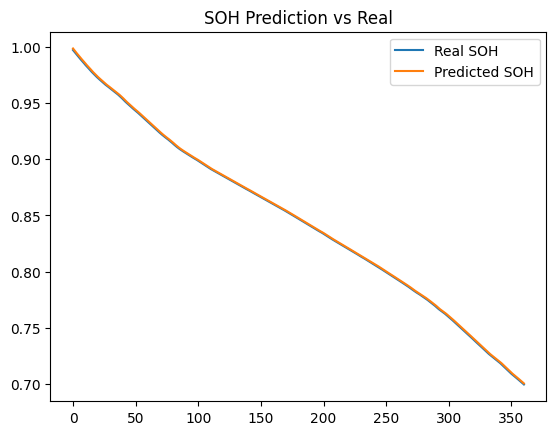

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["SOH"], label="Real SOH")
plt.plot(df["SOH_pred"], label="Predicted SOH")
plt.legend()
plt.title("SOH Prediction vs Real")
plt.show()

**Dataset_2**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/outputs/features_2.csv')

# sécurité
if "SOH_lag_1" not in df.columns:
    df["SOH_lag_1"] = df["SOH"].shift(1)

df = df.dropna().reset_index(drop=True)

print("Dataset loaded ✅")

Dataset loaded ✅


In [ ]:
results = []

for i in range(len(df)):
    pred = predict(df.iloc[i])
    results.append(pred)

df["SOH_pred"] = results

print("Prediction done ✅")

Prediction done ✅


In [ ]:
df[["SOH", "SOH_pred"]].head()

,SOH,SOH_pred
0,0.999883,0.999908
1,0.999822,0.999841
2,0.999755,0.999780
3,0.999693,0.999713
4,0.999627,0.999651


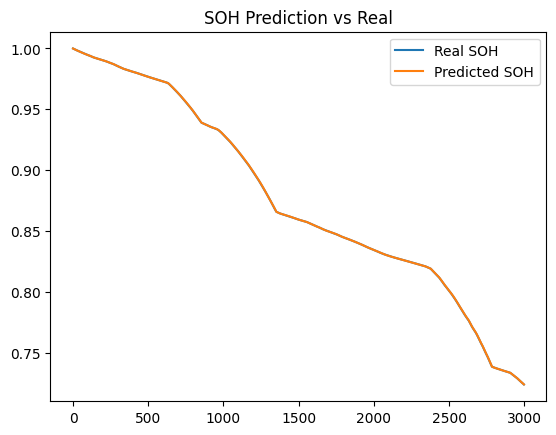

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["SOH"], label="Real SOH")
plt.plot(df["SOH_pred"], label="Predicted SOH")
plt.legend()
plt.title("SOH Prediction vs Real")
plt.show()

**Dataset_3(without feature_engineering)**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/battery_dataset_Panasonic_NCR18650B_2S1P.csv')

# sécurité
if "SOH_lag_1" not in df.columns:
    df["SOH_lag_1"] = df["SOH"].shift(1)

df = df.dropna().reset_index(drop=True)

print("Dataset loaded ✅")

Dataset loaded ✅


In [ ]:
results = []

for i in range(len(df)):
    pred = predict(df.iloc[i])
    results.append(pred)

df["SOH_pred"] = results

print("Prediction done ✅")

Prediction done ✅


In [ ]:
df[["SOH", "SOH_pred"]].head()

,SOH,SOH_pred
0,0.997299,NaN
1,0.995931,NaN
2,0.994493,NaN
3,0.993118,NaN
4,0.991688,NaN


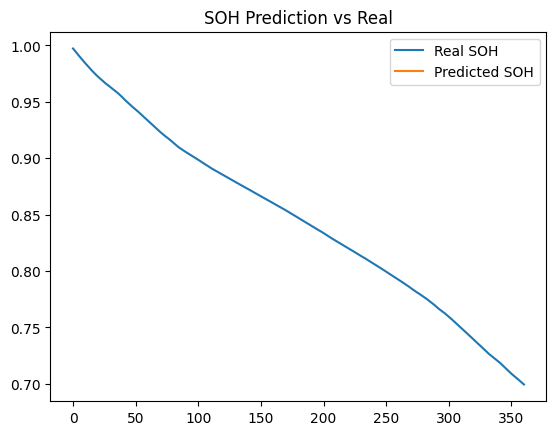

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["SOH"], label="Real SOH")
plt.plot(df["SOH_pred"], label="Predicted SOH")
plt.legend()
plt.title("SOH Prediction vs Real")
plt.show()